# Lecture 9 · IoU & bounding-box losses from scratch

**Goal** · compute Intersection-over-Union between two boxes (reproduce $0.143$), the $L_1$ / smooth-$L_1$ box-regression losses (reproduce $0.35$), and visualise the overlap.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 1 · Intersection over Union

$$\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}.$$  Boxes are $(x_{min},y_{min},x_{max},y_{max})$.

In [2]:
def iou(a, b):
    ix0, iy0 = max(a[0], b[0]), max(a[1], b[1])
    ix1, iy1 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix1 - ix0) * max(0, iy1 - iy0)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union, inter, union

A = (0, 0, 10, 10)      # area 100
B = (5, 5, 15, 15)      # area 100
val, inter, union = iou(A, B)
print(f'intersection = {inter}, union = {union}, IoU = {val:.3f}  (lecture 25/175 = 0.143)')

intersection = 25, union = 175, IoU = 0.143  (lecture 25/175 = 0.143)


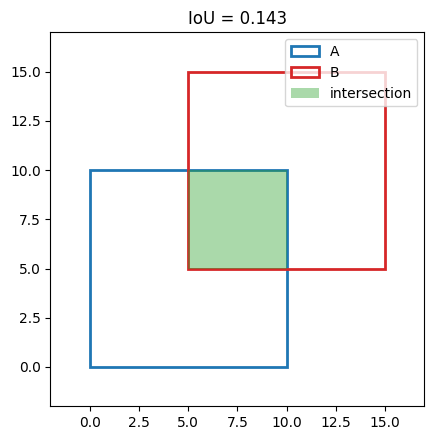

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.add_patch(mpatches.Rectangle((A[0], A[1]), A[2]-A[0], A[3]-A[1], fill=False, ec='C0', lw=2, label='A'))
ax.add_patch(mpatches.Rectangle((B[0], B[1]), B[2]-B[0], B[3]-B[1], fill=False, ec='C3', lw=2, label='B'))
ax.add_patch(mpatches.Rectangle((5, 5), 5, 5, fc='C2', alpha=0.4, label='intersection'))
ax.set_xlim(-2, 17); ax.set_ylim(-2, 17); ax.set_aspect('equal'); ax.legend()
ax.set_title(f'IoU = {val:.3f}'); plt.tight_layout(); plt.show()

## 2 · Box-regression losses

Coordinates $(x_c,y_c,w,h)$. Smooth-$L_1$ is quadratic near 0 and linear for large errors:

$$\mathrm{smooth}_{L_1}(r)=\begin{cases}0.5r^2 & |r|<1\\ |r|-0.5 & \text{otherwise}\end{cases}$$

In [4]:
b_true = np.array([0.5, 0.5, 0.4, 0.2])
b_pred = np.array([0.6, 0.45, 0.5, 0.3])
r = b_pred - b_true

def smooth_l1(r):
    a = np.abs(r)
    return np.where(a < 1, 0.5 * r ** 2, a - 0.5)

print('residuals      :', np.round(r, 3))
print('L1 loss (sum)  :', round(float(np.abs(r).sum()), 4), ' (lecture 0.35)')
print('smooth-L1 (sum):', round(float(smooth_l1(r).sum()), 4))

residuals      : [ 0.1  -0.05  0.1   0.1 ]
L1 loss (sum)  : 0.35  (lecture 0.35)
smooth-L1 (sum): 0.0162


## 3 · Why smooth-$L_1$?

It behaves like $L_2$ for small residuals (stable gradients) but like $L_1$ for large ones (robust to outliers).

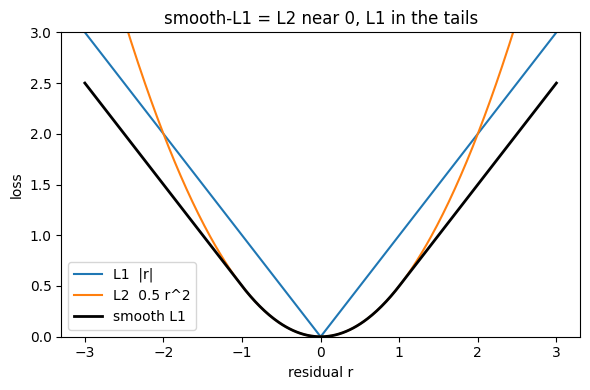

In [5]:
rr = np.linspace(-3, 3, 400)
plt.figure(figsize=(6, 4))
plt.plot(rr, np.abs(rr), label='L1  |r|')
plt.plot(rr, 0.5 * rr ** 2, label='L2  0.5 r^2')
plt.plot(rr, smooth_l1(rr), 'k', lw=2, label='smooth L1')
plt.ylim(0, 3); plt.xlabel('residual r'); plt.ylabel('loss'); plt.legend()
plt.title('smooth-L1 = L2 near 0, L1 in the tails')
plt.tight_layout(); plt.show()

## Takeaway

- IoU measures overlap directly; coordinate losses do not (motivating IoU/GIoU losses).
- $L_1$ on our worked boxes = $0.35$; smooth-$L_1$ softens the gradient near zero error.
- Detection combines a classification loss with such a box-regression loss.